<a href="https://colab.research.google.com/github/sharifa-15/adult-income-prediction-ml/blob/main/Adult_Census_Income_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Predictive Modeling on Adult Census Income Dataset
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, roc_curve, auc
)

In [5]:

# 1. Load dataset
data = pd.read_csv("adult.csv")

In [6]:

# 2. Preprocessing
# Drop rows with missing values represented as '?'
data = data.replace('?', pd.NA).dropna()

In [7]:
# Encode categorical variables
label_enc = LabelEncoder()
for col in data.select_dtypes(include=['object']).columns:
    data[col] = label_enc.fit_transform(data[col])

In [8]:

# Features and target
X = data.drop("income", axis=1)   # 'income' is the target column (>50K or <=50K)
y = data["income"]

In [9]:
# Scale features (important for Logistic Regression)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [10]:
# 3. Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

In [11]:
# 4. Initialize models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

In [12]:

# 5. Train & evaluate
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"\n{name} Accuracy: {acc:.4f}")
    print(classification_report(y_test, y_pred))


Logistic Regression Accuracy: 0.8077
              precision    recall  f1-score   support

           0       0.83      0.93      0.88      3380
           1       0.71      0.48      0.57      1242

    accuracy                           0.81      4622
   macro avg       0.77      0.70      0.72      4622
weighted avg       0.80      0.81      0.79      4622


Random Forest Accuracy: 0.8488
              precision    recall  f1-score   support

           0       0.88      0.92      0.90      3380
           1       0.75      0.65      0.70      1242

    accuracy                           0.85      4622
   macro avg       0.82      0.79      0.80      4622
weighted avg       0.84      0.85      0.84      4622



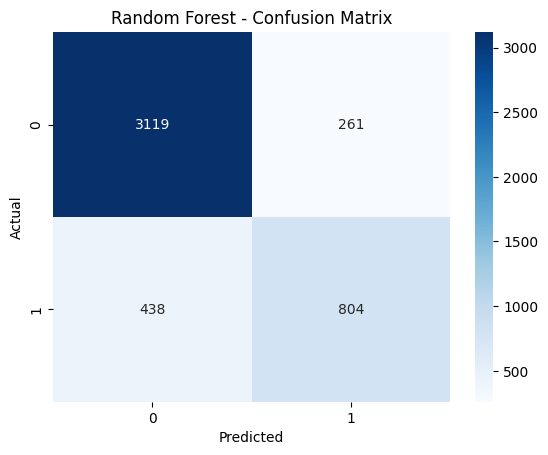

In [14]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f"{name} - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

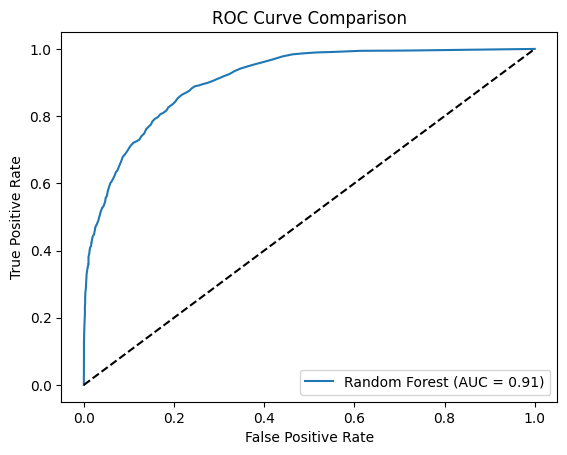

In [16]:
# ROC Curve
if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:,1]
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.2f})")

plt.plot([0,1],[0,1],'k--')
plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()